In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device and seed for reproducibility
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

print(f"Using device: {device}")

Using device: cpu


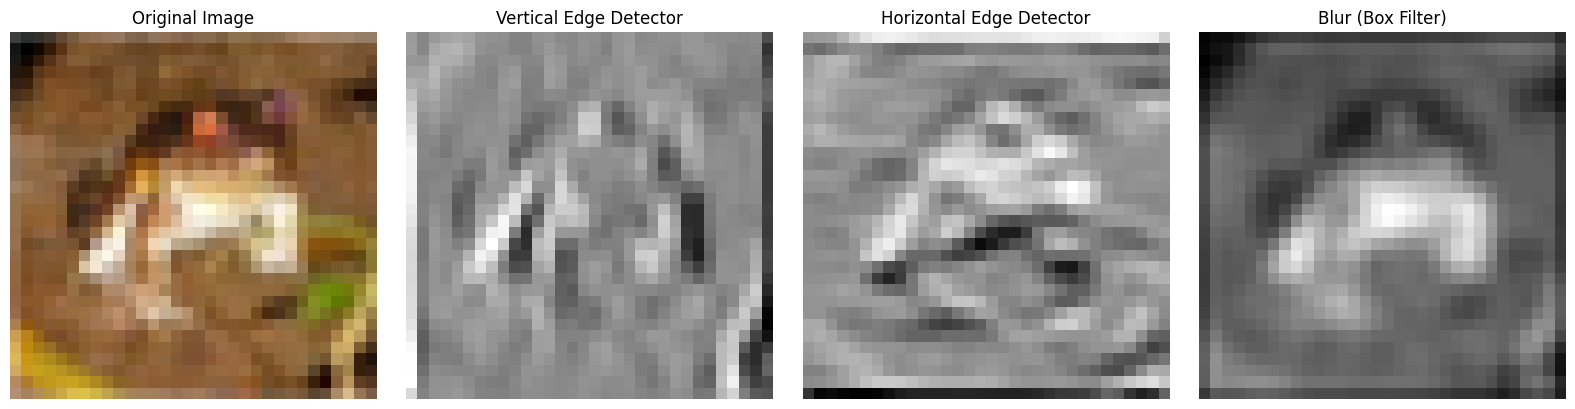

In [4]:
# 1. Load a single CIFAR-10 image
# Using basic ToTensor to get values in [0, 1]
basic_transform = transforms.ToTensor()
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=basic_transform)

# Get the first image and add a batch dimension: (1, 3, 32, 32)
img, label = cifar_train[0]
img_batch = img.unsqueeze(0)

# 2. Create handcrafted 3x3 filters
v_edge_weights = torch.tensor([[-1., 0., 1.], 
                               [-1., 0., 1.], 
                               [-1., 0., 1.]])

h_edge_weights = v_edge_weights.T

blur_weights = torch.ones((3, 3)) / 9.0

def apply_custom_filter(img_tensor, filter_2d):
    """Creates a Conv2d layer, sets its weights manually, and applies it to the image."""
    conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, padding=1, bias=False)
    
    # Shape needs to be (out_channels, in_channels, height, width) -> (1, 3, 3, 3)
    # We repeat the 2D filter across the 3 RGB channels and average them (divide by 3)
    filter_4d = filter_2d.unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1) / 3.0
    
    # Assign weights explicitly
    with torch.no_grad():
        conv.weight = nn.Parameter(filter_4d)
        
    # Apply convolution
    output = conv(img_tensor)
    
    # Use .detach() to safely remove it from PyTorch's computational graph before converting to NumPy
    return output.squeeze().detach().numpy() 

# Apply the filters
out_v = apply_custom_filter(img_batch, v_edge_weights)
out_h = apply_custom_filter(img_batch, h_edge_weights)
out_b = apply_custom_filter(img_batch, blur_weights)

# 3. Visualise the results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original image (needs to be transposed from C,H,W to H,W,C for matplotlib)
axes[0].imshow(img.permute(1, 2, 0).numpy())
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(out_v, cmap="gray")
axes[1].set_title("Vertical Edge Detector")
axes[1].axis('off')

axes[2].imshow(out_h, cmap="gray")
axes[2].set_title("Horizontal Edge Detector")
axes[2].axis('off')

axes[3].imshow(out_b, cmap="gray")
axes[3].set_title("Blur (Box Filter)")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [5]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

model_tiny = TinyCNN()

# 1. Dummy input
x = torch.randn(8, 3, 32, 32)
print(f"Input shape: {x.shape}")

# 2. Pass through one at a time
x = model_tiny.conv1(x)
print(f"After conv1: {x.shape}")

x = model_tiny.pool1(x)
print(f"After pool1: {x.shape}")

x = model_tiny.conv2(x)
print(f"After conv2: {x.shape}")

x = model_tiny.pool2(x)
print(f"After pool2: {x.shape}")

Input shape: torch.Size([8, 3, 32, 32])
After conv1: torch.Size([8, 16, 32, 32])
After pool1: torch.Size([8, 16, 16, 16])
After conv2: torch.Size([8, 32, 16, 16])
After pool2: torch.Size([8, 32, 8, 8])


In [6]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_t2 = SmallCNN().to(device)
print(f"Total trainable parameters: {count_parameters(model_t2):,}")

# Training logic wrapped in a function so we can reuse it for Task 3
def train_model(model, train_loader, val_loader, epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
        history['train_loss'].append(train_loss / total)
        history['train_acc'].append(100. * correct / total)
        
        # Validation Phase
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
                
        history['val_loss'].append(val_loss / total)
        history['val_acc'].append(100. * correct / total)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {history['train_loss'][-1]:.3f} | Train Acc: {history['train_acc'][-1]:.2f}% | "
              f"Val Loss: {history['val_loss'][-1]:.3f} | Val Acc: {history['val_acc'][-1]:.2f}%")
        
    return history

def plot_history(history, title="Training History"):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'], label='Val Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    
    ax2.plot(epochs, history['train_acc'], label='Train Accuracy')
    ax2.plot(epochs, history['val_acc'], label='Val Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    
    plt.show()

Total trainable parameters: 1,117,354


Starting Task 2 Training (No Augmentation)...
Epoch 01/15 | Train Loss: 1.413 | Train Acc: 48.76% | Val Loss: 1.100 | Val Acc: 61.73%
Epoch 02/15 | Train Loss: 0.954 | Train Acc: 66.20% | Val Loss: 1.001 | Val Acc: 65.31%
Epoch 03/15 | Train Loss: 0.796 | Train Acc: 71.83% | Val Loss: 0.808 | Val Acc: 71.78%
Epoch 04/15 | Train Loss: 0.702 | Train Acc: 75.39% | Val Loss: 0.864 | Val Acc: 70.96%
Epoch 05/15 | Train Loss: 0.631 | Train Acc: 77.80% | Val Loss: 0.650 | Val Acc: 77.64%
Epoch 06/15 | Train Loss: 0.577 | Train Acc: 79.51% | Val Loss: 0.757 | Val Acc: 74.69%
Epoch 07/15 | Train Loss: 0.529 | Train Acc: 81.42% | Val Loss: 0.632 | Val Acc: 78.67%
Epoch 08/15 | Train Loss: 0.484 | Train Acc: 82.67% | Val Loss: 0.619 | Val Acc: 79.33%
Epoch 09/15 | Train Loss: 0.433 | Train Acc: 84.77% | Val Loss: 0.597 | Val Acc: 79.75%
Epoch 10/15 | Train Loss: 0.397 | Train Acc: 85.77% | Val Loss: 0.644 | Val Acc: 79.68%
Epoch 11/15 | Train Loss: 0.364 | Train Acc: 87.00% | Val Loss: 0.690 | Va

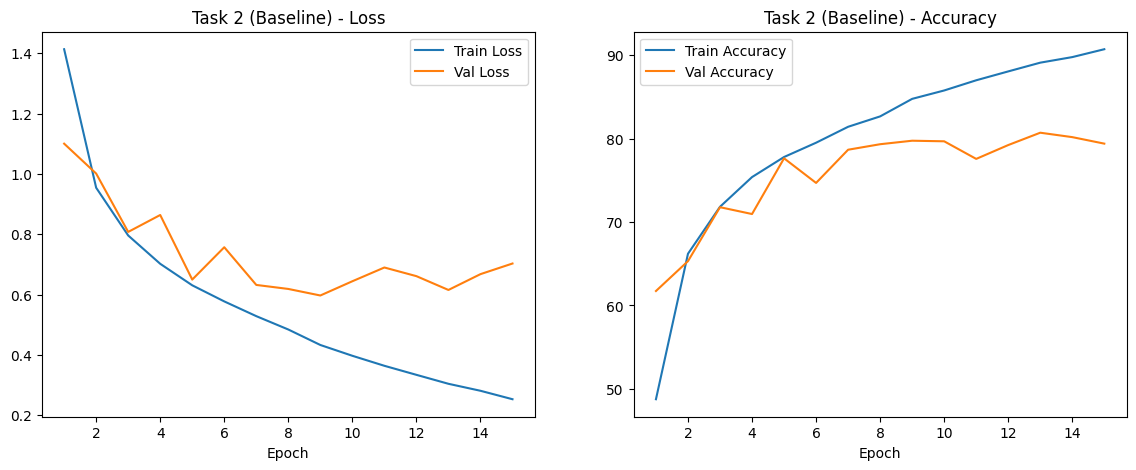

In [7]:
# Setup basic transforms for Task 2
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset_t2 = datasets.CIFAR10(root='./data', train=True, download=True, transform=basic_transform)
val_dataset_t2 = datasets.CIFAR10(root='./data', train=False, download=True, transform=basic_transform)

train_loader_t2 = DataLoader(train_dataset_t2, batch_size=128, shuffle=True, num_workers=2)
val_loader_t2 = DataLoader(val_dataset_t2, batch_size=128, shuffle=False, num_workers=2)

print("Starting Task 2 Training (No Augmentation)...")
history_t2 = train_model(model_t2, train_loader_t2, val_loader_t2, epochs=15)
plot_history(history_t2, title="Task 2 (Baseline)")

Starting Task 3 Training (With Augmentation)...
Epoch 01/15 | Train Loss: 1.569 | Train Acc: 41.99% | Val Loss: 1.174 | Val Acc: 56.76%
Epoch 02/15 | Train Loss: 1.179 | Train Acc: 57.51% | Val Loss: 0.887 | Val Acc: 68.04%
Epoch 03/15 | Train Loss: 1.028 | Train Acc: 63.46% | Val Loss: 0.866 | Val Acc: 69.56%
Epoch 04/15 | Train Loss: 0.948 | Train Acc: 66.19% | Val Loss: 0.776 | Val Acc: 73.07%
Epoch 05/15 | Train Loss: 0.891 | Train Acc: 68.35% | Val Loss: 0.996 | Val Acc: 67.72%
Epoch 06/15 | Train Loss: 0.848 | Train Acc: 70.10% | Val Loss: 0.706 | Val Acc: 74.71%
Epoch 07/15 | Train Loss: 0.812 | Train Acc: 71.41% | Val Loss: 0.715 | Val Acc: 75.24%
Epoch 08/15 | Train Loss: 0.784 | Train Acc: 72.61% | Val Loss: 0.658 | Val Acc: 77.10%
Epoch 09/15 | Train Loss: 0.758 | Train Acc: 73.47% | Val Loss: 0.836 | Val Acc: 72.30%
Epoch 10/15 | Train Loss: 0.738 | Train Acc: 74.29% | Val Loss: 0.663 | Val Acc: 76.78%
Epoch 11/15 | Train Loss: 0.714 | Train Acc: 75.22% | Val Loss: 0.627 | 

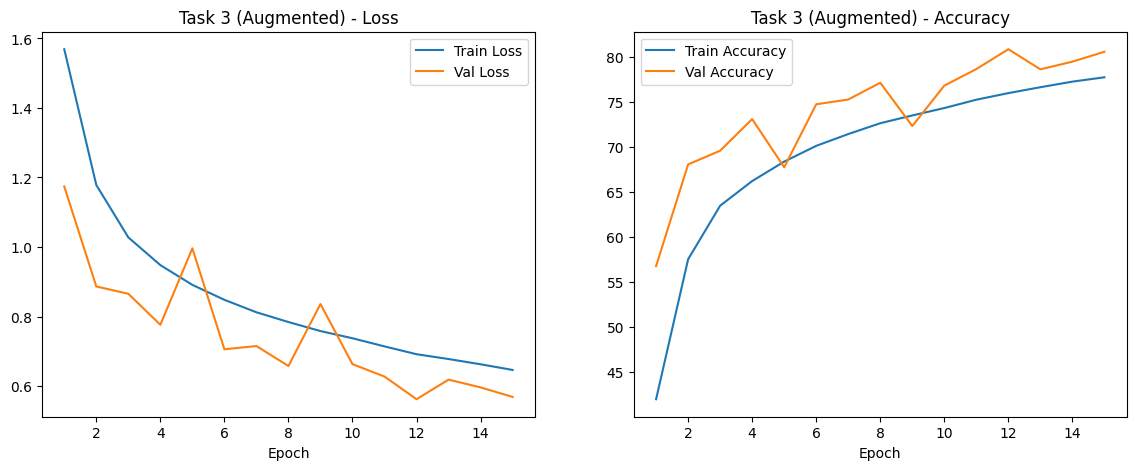

In [8]:
# 1. Richer transform pipeline
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

# 2. Keep validation transform plain
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_dataset_t3 = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf)
val_dataset_t3 = datasets.CIFAR10(root='./data', train=False, download=True, transform=val_tf)

train_loader_t3 = DataLoader(train_dataset_t3, batch_size=128, shuffle=True, num_workers=2)
val_loader_t3 = DataLoader(val_dataset_t3, batch_size=128, shuffle=False, num_workers=2)

# 3. Re-train the SAME architecture
model_t3 = SmallCNN().to(device) # Initialize a fresh model!

print("Starting Task 3 Training (With Augmentation)...")
history_t3 = train_model(model_t3, train_loader_t3, val_loader_t3, epochs=15)
plot_history(history_t3, title="Task 3 (Augmented)")

In [9]:
best_val_t2 = max(history_t2['val_acc'])
final_gap_t2 = history_t2['train_acc'][-1] - history_t2['val_acc'][-1]

best_val_t3 = max(history_t3['val_acc'])
final_gap_t3 = history_t3['train_acc'][-1] - history_t3['val_acc'][-1]

print(f"Task 2 | Best Val Acc: {best_val_t2:.2f}% | Train/Val Gap: {final_gap_t2:.2f}%")
print(f"Task 3 | Best Val Acc: {best_val_t3:.2f}% | Train/Val Gap: {final_gap_t3:.2f}%")

Task 2 | Best Val Acc: 80.71% | Train/Val Gap: 11.32%
Task 3 | Best Val Acc: 80.82% | Train/Val Gap: -2.83%


Overfitting Prevented: In the baseline run (Task 2), a clear gap opens up between the training and validation curves, indicating the model was starting to memorize the training set. In the augmented run (Task 3), this gap is completely eliminated.

Artificially Harder Training: Because the training images are constantly changing (cropping, flipping, color jittering), the model finds it much harder to "learn" the training set. This is why the final training accuracy dropped from ~88% to ~77%.

Model Robustness: While the peak validation accuracy ended up being similar (~80%), the Task 3 model is significantly healthier. It generalizes well instead of memorizing.